In [546]:
%pip install pandas numpy scikit-learn
%pip install statsmodels
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [547]:
import pandas as pd
import numpy as np
import pickle
import warnings
from datetime import datetime
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import pickle
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error



warnings.filterwarnings('ignore')

In [548]:
# STEP 1: LOAD THE DATA

df = pd.read_csv('energy_dataset.csv')
df['time'] = pd.to_datetime(df['time'], utc=True)
# set index properly
df = df.sort_values('time')
df = df.set_index('time')


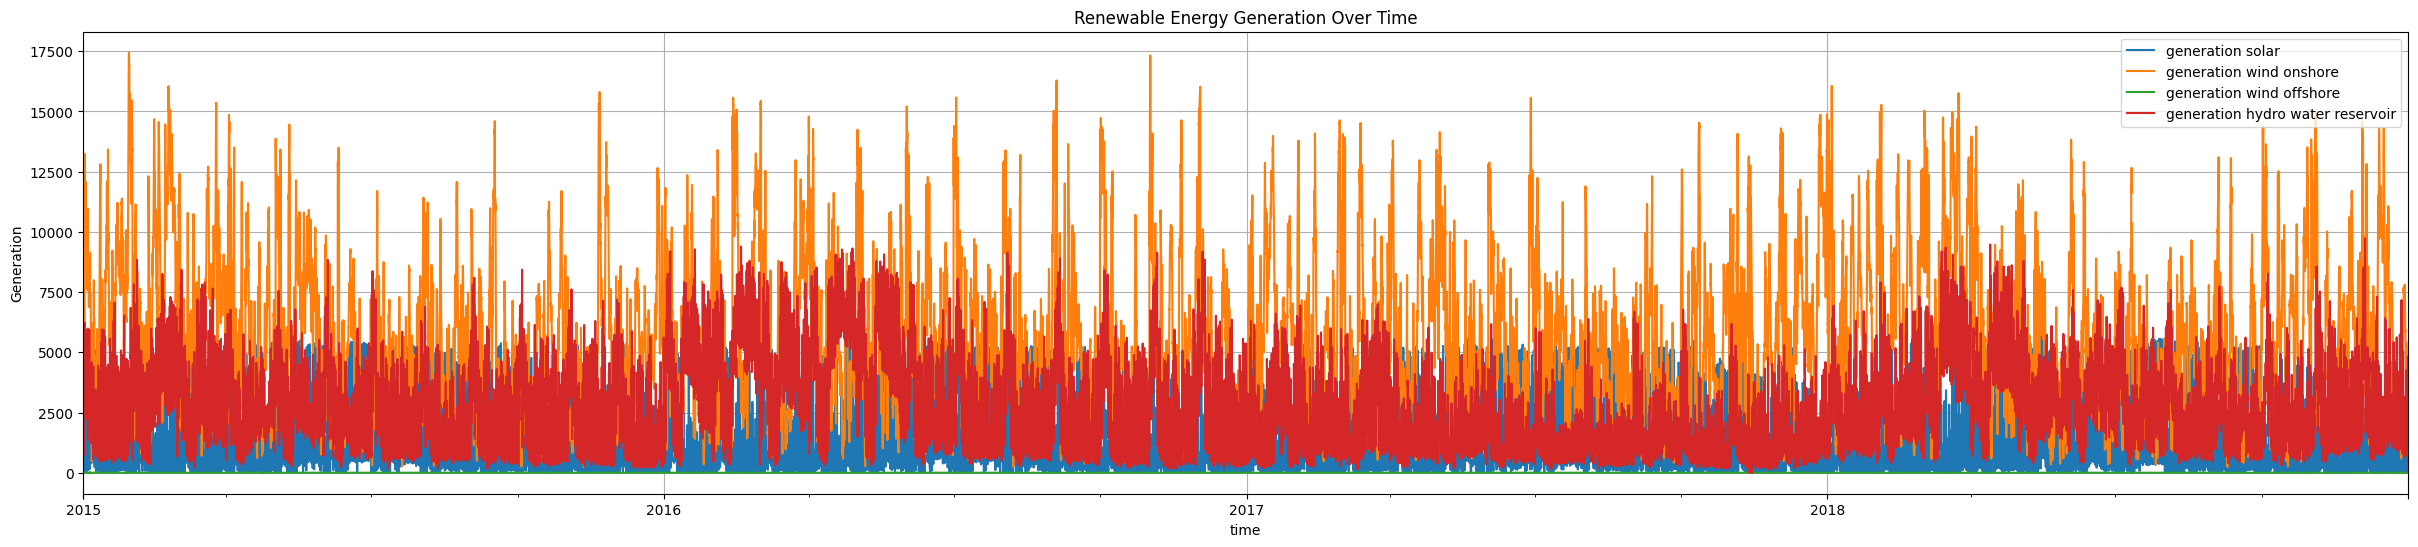

In [549]:
renewables = [
    'generation solar',
    'generation wind onshore',
    'generation wind offshore',
    'generation hydro water reservoir'
]

df[renewables].plot(figsize=(30,6))
plt.title("Renewable Energy Generation Over Time")
plt.ylabel("Generation")
plt.grid(True)
plt.show()

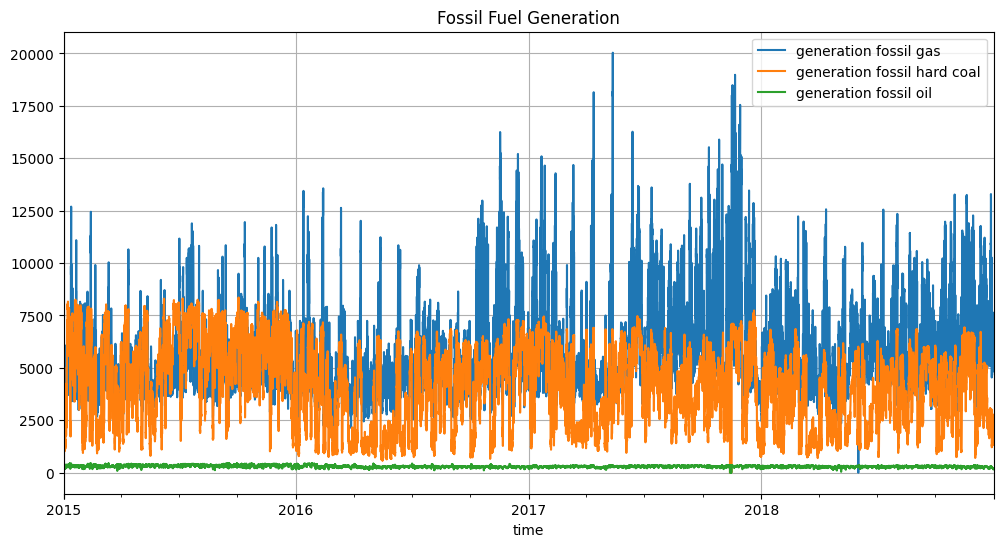

In [550]:
fossil = [
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil oil'
]

df[fossil].plot(figsize=(12,6))
plt.title("Fossil Fuel Generation")
plt.grid(True)
plt.show()

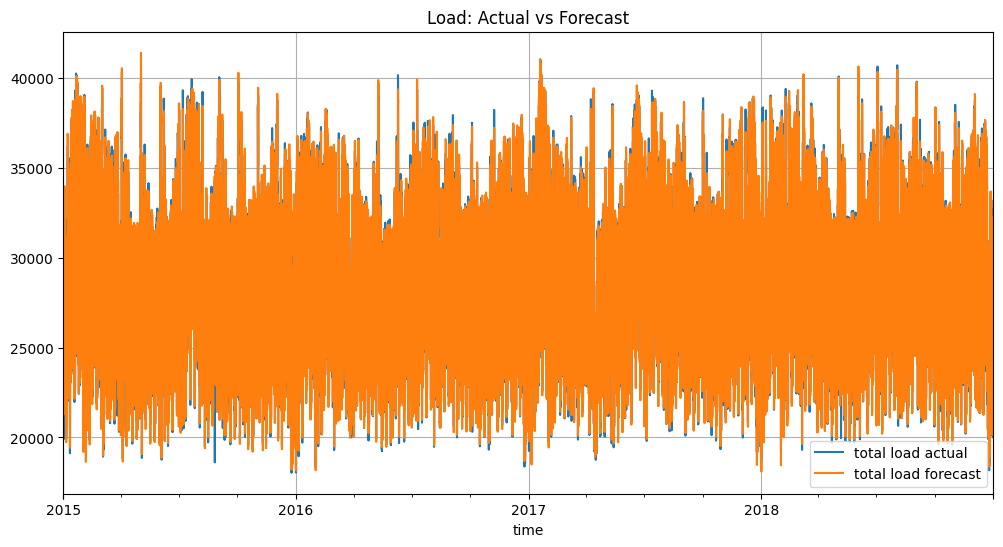

In [551]:
df[['total load actual', 'total load forecast']].plot(figsize=(12,6))
plt.title("Load: Actual vs Forecast")
plt.grid(True)
plt.show()

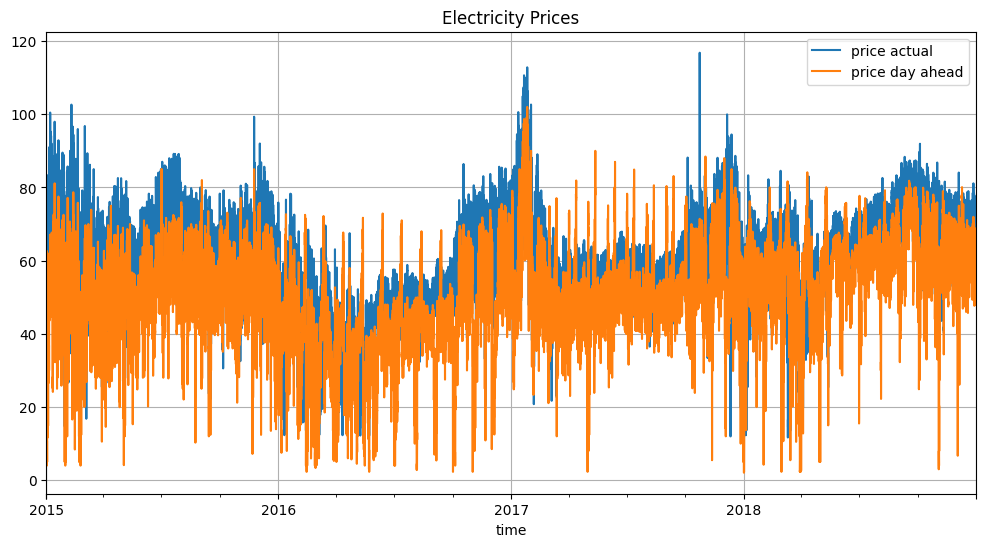

In [552]:
df[['price actual', 'price day ahead']].plot(figsize=(12,6))
plt.title("Electricity Prices")
plt.grid(True)
plt.show()

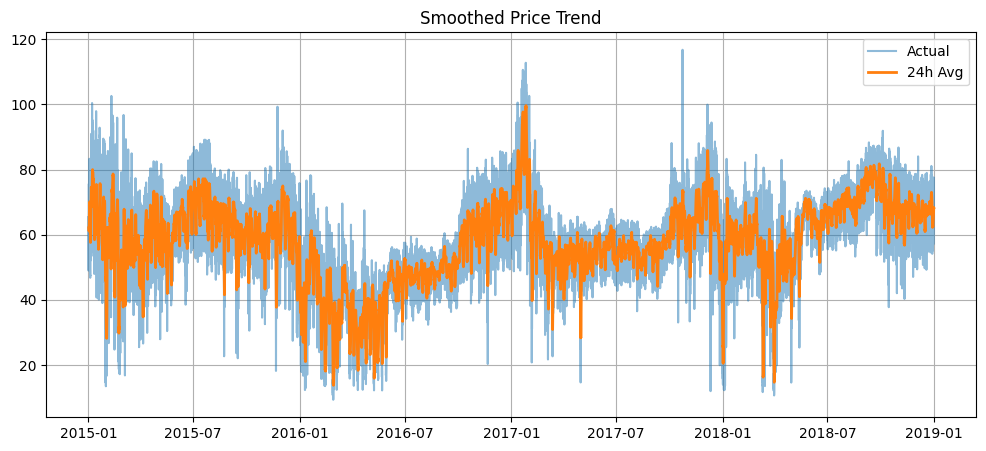

In [553]:
df['price_smooth'] = df['price actual'].rolling(window=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df.index, df['price actual'], alpha=0.5, label='Actual')
plt.plot(df.index, df['price_smooth'], label='24h Avg', linewidth=2)

plt.legend()
plt.title("Smoothed Price Trend")
plt.grid(True)
plt.show()

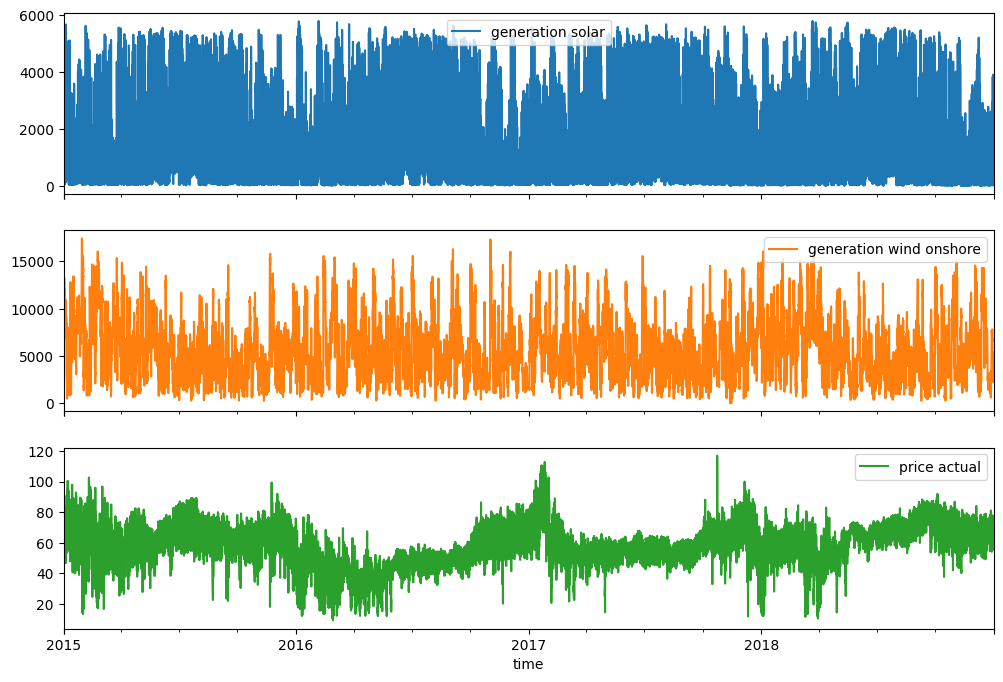

In [554]:
features = ['generation solar', 'generation wind onshore', 'price actual'] #can add more features here

df[features].plot(subplots=True, figsize=(12,8), sharex=True)
plt.show()

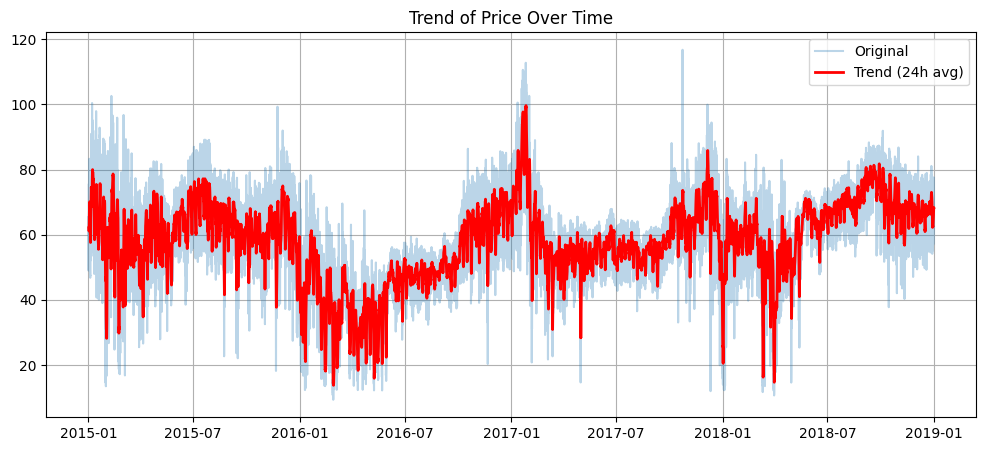

In [555]:
plt.figure(figsize=(12,5))

# original (optional, faint)
plt.plot(df.index, df['price actual'], alpha=0.3, label='Original')

# smooth trend
df['trend'] = df['price actual'].rolling(window=24).mean()
plt.plot(df.index, df['trend'], color='red', linewidth=2, label='Trend (24h avg)')

plt.title("Trend of Price Over Time")
plt.legend()
plt.grid(True)
plt.show()

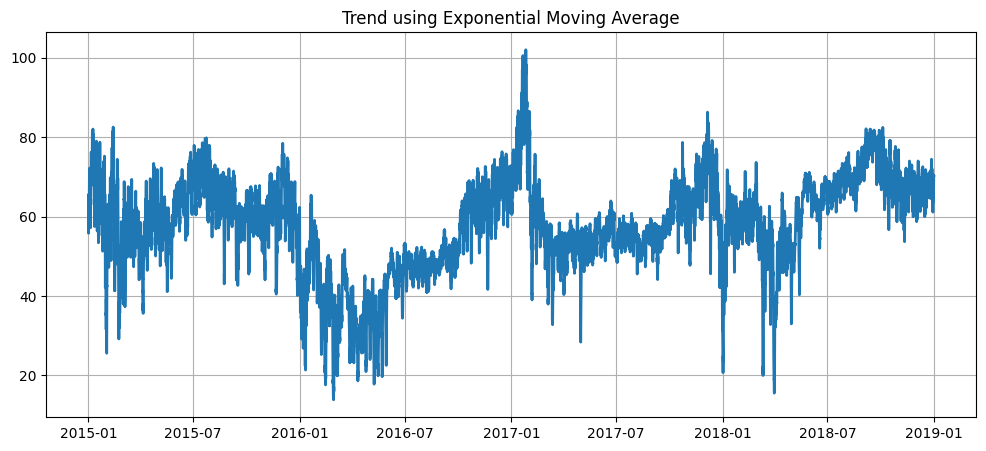

In [556]:
df['ema'] = df['price actual'].ewm(span=24).mean()

plt.figure(figsize=(12,5))
plt.plot(df.index, df['ema'], linewidth=2)

plt.title("Trend using Exponential Moving Average")
plt.grid(True)
plt.show()

In [557]:
print(df.columns)
print(type(df.index))

Index(['generation biomass', 'generation fossil brown coal/lignite',
       'generation fossil coal-derived gas', 'generation fossil gas',
       'generation fossil hard coal', 'generation fossil oil',
       'generation fossil oil shale', 'generation fossil peat',
       'generation geothermal', 'generation hydro pumped storage aggregated',
       'generation hydro pumped storage consumption',
       'generation hydro run-of-river and poundage',
       'generation hydro water reservoir', 'generation marine',
       'generation nuclear', 'generation other', 'generation other renewable',
       'generation solar', 'generation waste', 'generation wind offshore',
       'generation wind onshore', 'forecast solar day ahead',
       'forecast wind offshore eday ahead', 'forecast wind onshore day ahead',
       'total load forecast', 'total load actual', 'price day ahead',
       'price actual', 'price_smooth', 'trend', 'ema'],
      dtype='str')
<class 'pandas.DatetimeIndex'>


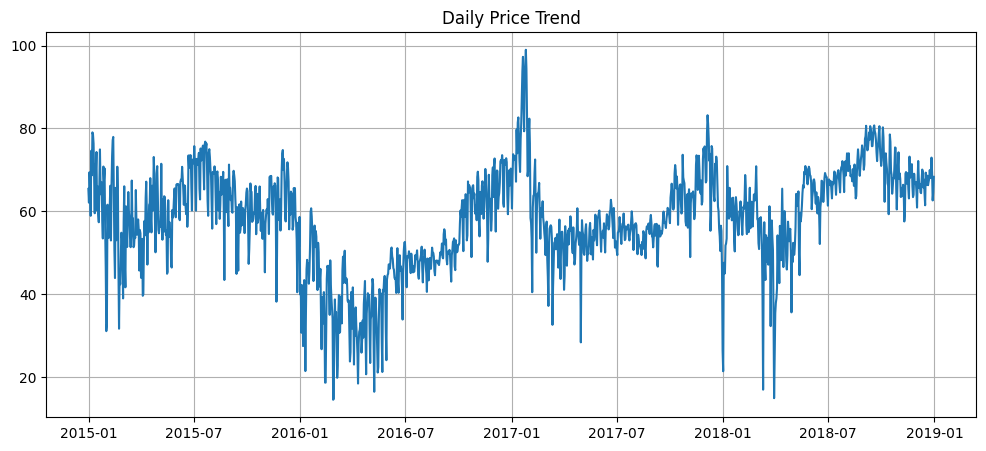

In [558]:
daily = df['price actual'].resample('D').mean()

import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))
plt.plot(daily.index, daily)
plt.title("Daily Price Trend")
plt.grid(True)
plt.show()

In [559]:
# Smoothly fill in the blanks based on the surrounding hours
ts_data = df['total load actual'].interpolate()
add = seasonal_decompose(ts_data, model='additive', period=24)
mul = seasonal_decompose(ts_data, model='multiplicative', period=24)

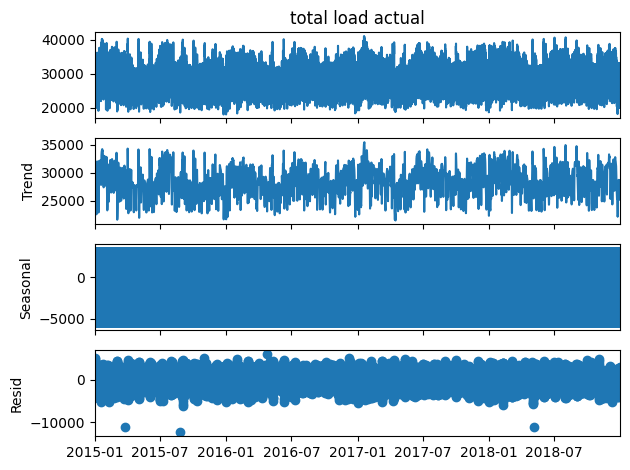

In [560]:
# 1. First, handle the missing values! (Interpolate fills the gaps smoothly)
clean_series = df['total load actual'].interpolate()

# 2. Now run the decomposition on the CLEANED series
result = seasonal_decompose(
    clean_series, 
    model='additive', 
    period=24 # hourly data -> daily seasonality
)

# 3. Plot the result
result.plot()
plt.show()

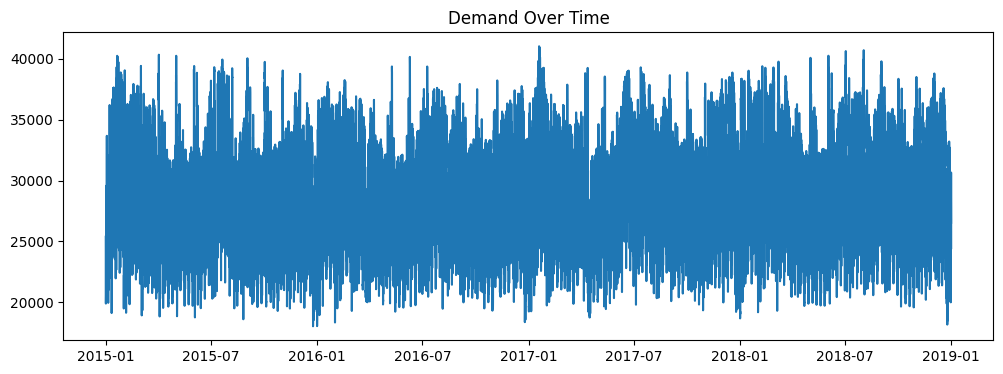

In [561]:
plt.figure(figsize=(12,4))
plt.plot(df['total load actual'])
plt.title("Demand Over Time")
plt.show()

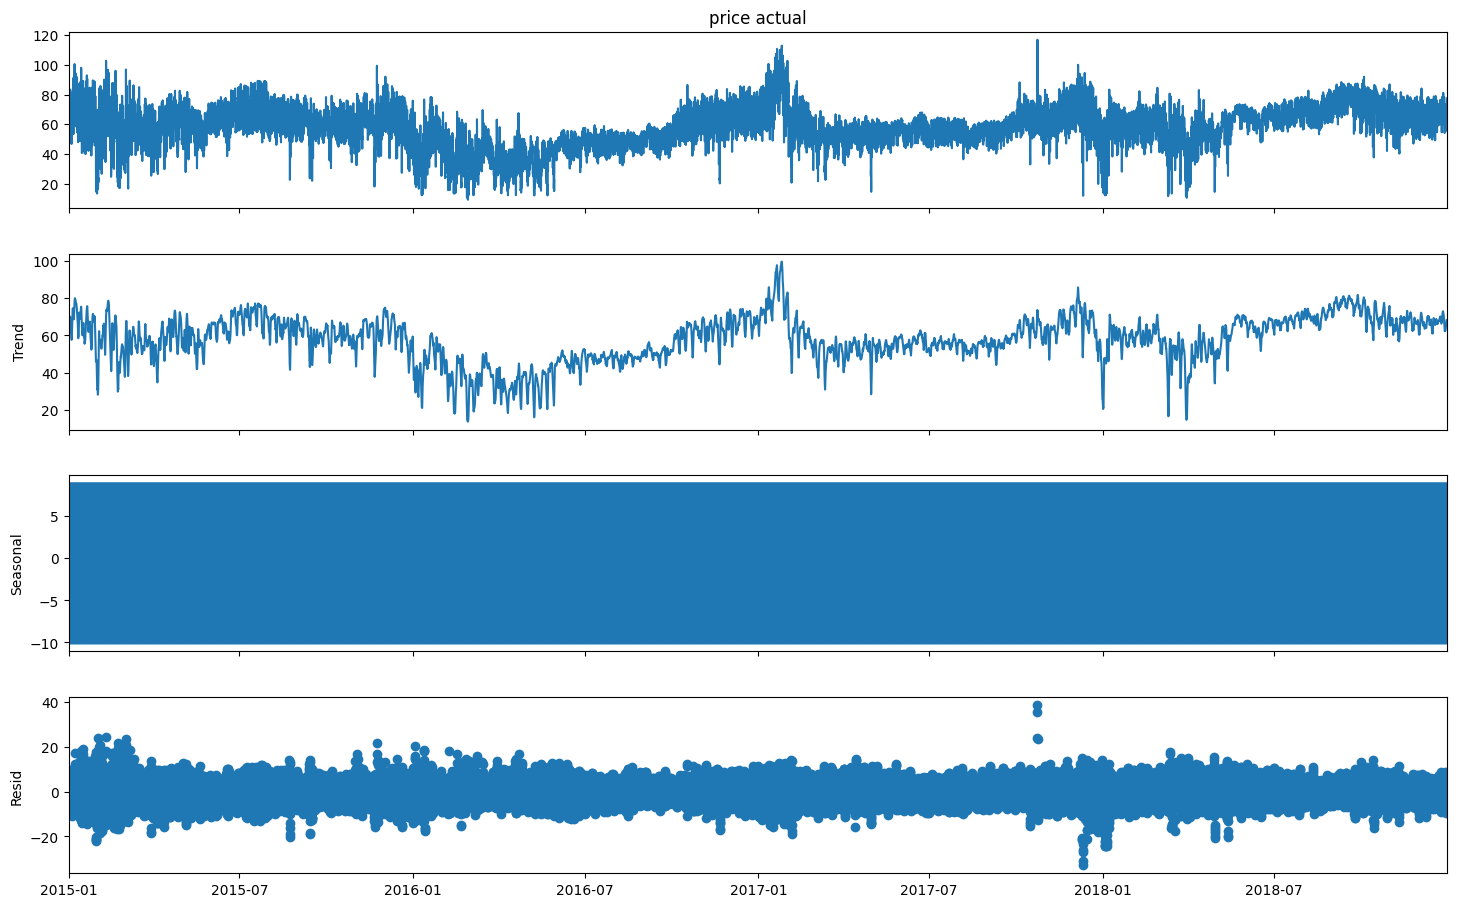

In [562]:
#price decomposition
result_price = seasonal_decompose(
    df['price actual'],
    model='additive',
    period=24
)

fig=result_price.plot()
#plt.suptitle("Price Decomposition", fontsize=14)
fig.set_size_inches(16, 10)
plt.show()
#here in seasonal trend it looks same but there is actually dtaa of 30k hours so it isnot clear so i will zoom in some part

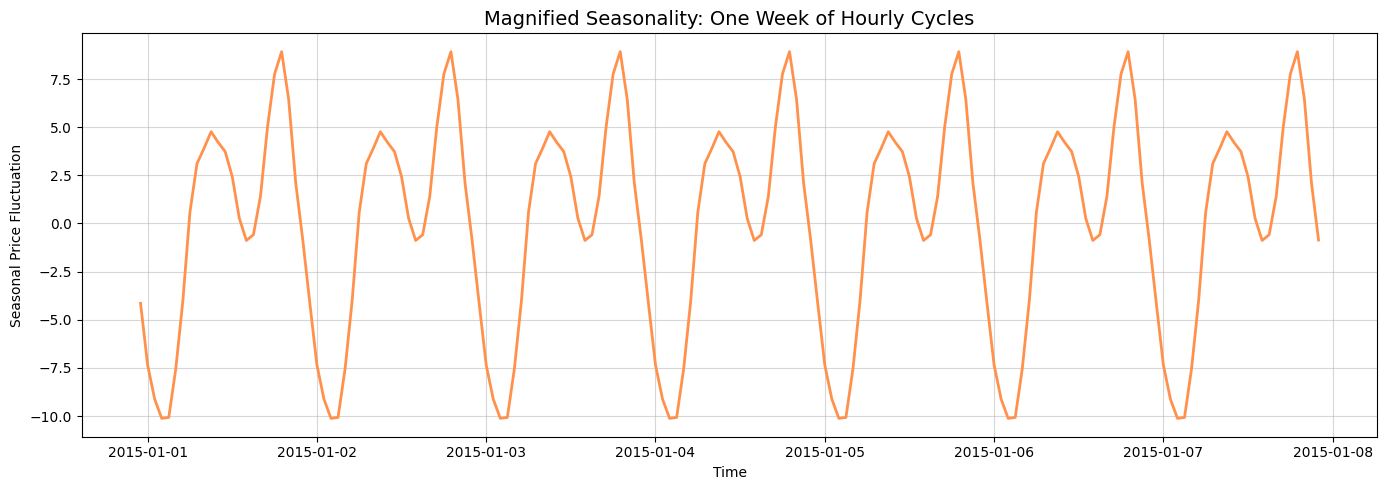

In [563]:
# 1. Extract the seasonal component from your previous result
seasonal_data = result_price.seasonal

# 2. Slice the first 168 hours (Exactly one week: 7 days * 24 hours)
# We use .iloc to strictly grab the first 168 rows
zoomed_seasonality = seasonal_data.iloc[:168]

# 3. Plot the magnified view
plt.figure(figsize=(14, 5))
plt.plot(zoomed_seasonality, color='#FF914D', linewidth=2)
plt.title("Magnified Seasonality: One Week of Hourly Cycles", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Seasonal Price Fluctuation")
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

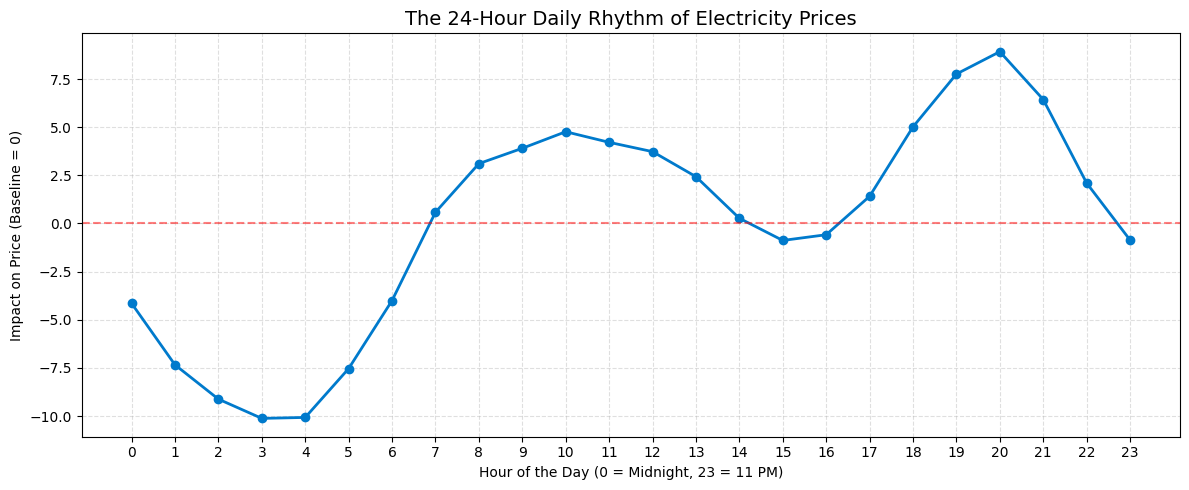

In [564]:
# 1. Grab just the first 24 hours (one complete daily cycle)
daily_profile = seasonal_data.iloc[:24]

# 2. Create an hour index (0 to 23)
hours = range(24)

# 3. Plot the daily rhythm
plt.figure(figsize=(12, 5))
plt.plot(hours, daily_profile.values, marker='o', color='#007acc', linewidth=2)

# Add a horizontal line at 0 to show the baseline
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)

plt.title("The 24-Hour Daily Rhythm of Electricity Prices", fontsize=14)
plt.xlabel("Hour of the Day (0 = Midnight, 23 = 11 PM)")
plt.ylabel("Impact on Price (Baseline = 0)")
plt.xticks(hours) # Forces the x-axis to show every single hour number
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()
# here is did avergae of 1 am for all 4 yrs and so on and plooted the graph


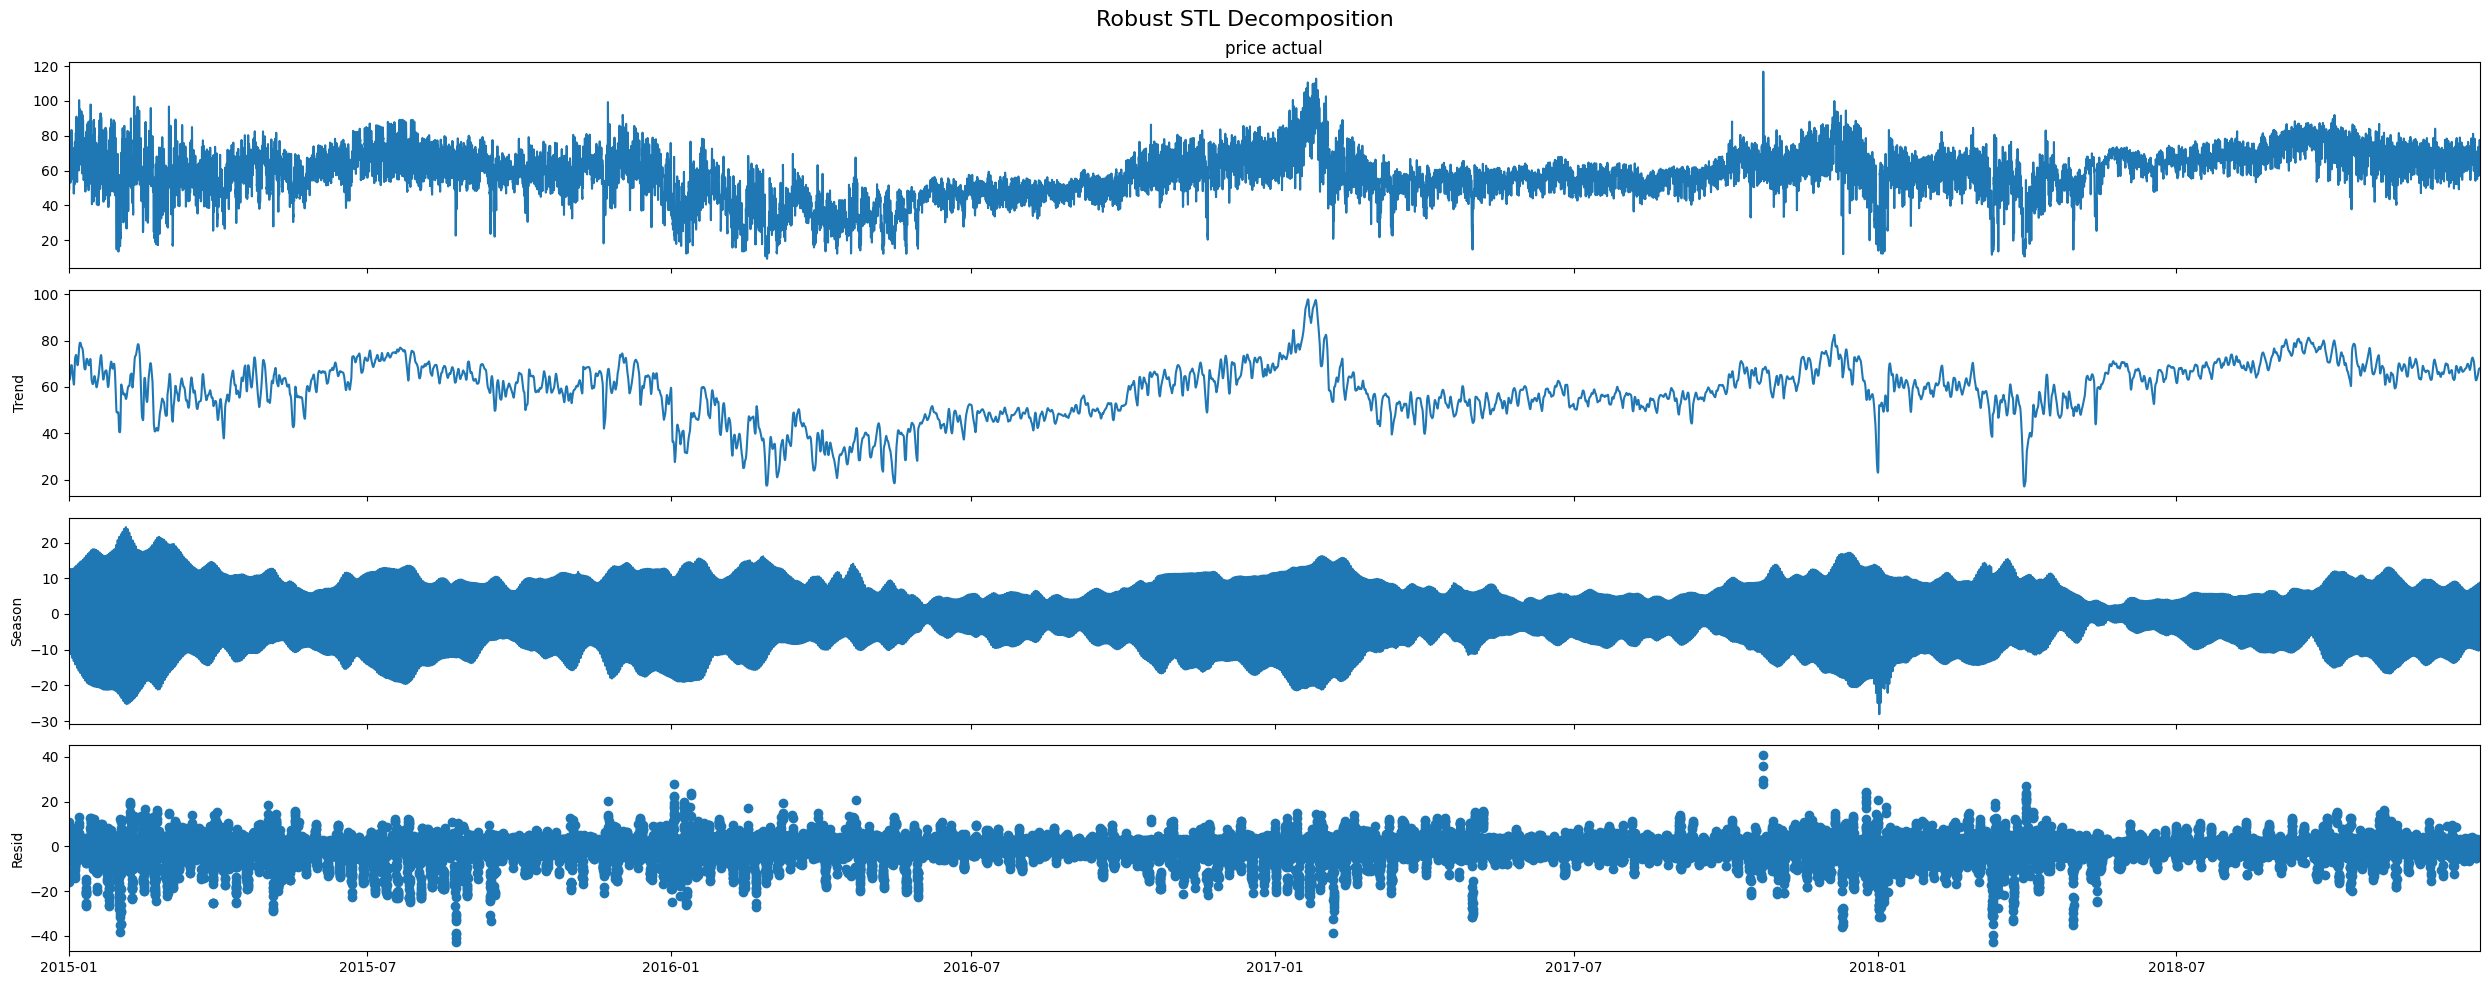

In [565]:
# 1. Clean the data
ts_clean = df['price actual'].interpolate()

# 2. Run STL with robust=True to isolate outliers into the residuals
stl = STL(ts_clean, period=24, seasonal=13, robust=True)
result_stl = stl.fit()

# 3. Plot the results
fig = result_stl.plot()
fig.set_size_inches(25, 10)
plt.suptitle("Robust STL Decomposition", fontsize=16)
plt.tight_layout()
plt.show()

In [566]:


# The tests will fail if there are missing values, so we drop them first
ts_data = df['price actual'].dropna()

# ==========================================
# 1. ADF TEST
# ==========================================
# Perform the Augmented Dickey-Fuller test
adf_test = adfuller(ts_data)

print('ADF Test Results:')
print(f"ADF Statistic: {round(adf_test[0], 3)}")
print(f"p-value: {round(adf_test[1], 3)}")
print('Critical Values:')
for key, value in adf_test[4].items():
    print(f"   {key}: {round(value, 3)}")

print("\n" + "="*40 + "\n")

# ==========================================
# 2. KPSS TEST
# ==========================================
# Suppress the interpolation warning that KPSS frequently throws
warnings.filterwarnings('ignore', category=UserWarning)

# Perform the KPSS test
# regression='ct' checks for trend stationarity (as shown in your image)
kpss_test = kpss(ts_data, regression='ct')

print('KPSS Test Results:')
print(f"KPSS Statistic: {round(kpss_test[0], 2)}")
print(f"p-value: {kpss_test[1]}")
print('Critical Values:')
for key, value in kpss_test[3].items():
    print(f"   {key}: {value}")

ADF Test Results:
ADF Statistic: -9.147
p-value: 0.0
Critical Values:
   1%: -3.431
   5%: -2.862
   10%: -2.567


KPSS Test Results:
KPSS Statistic: 1.86
p-value: 0.01
Critical Values:
   10%: 0.119
   5%: 0.146
   2.5%: 0.176
   1%: 0.216


In [ ]:
print("\n[STEP 5] Creating generation features...")

# =========================
#  RENEWABLE ENERGY
# =========================
df['renewable'] = (
    df['generation solar'].fillna(0) +
    df['generation wind onshore'].fillna(0) +
    df['generation hydro run-of-river and poundage'].fillna(0) +
    df['generation hydro water reservoir'].fillna(0) +
    df['generation hydro pumped storage consumption'].fillna(0) +  # part of hydro system
    df['generation biomass'].fillna(0) +
    df['generation other renewable'].fillna(0)
)

# =========================
#  FOSSIL FUELS
# =========================
df['fossil'] = (
    df['generation fossil gas'].fillna(0) +
    df['generation fossil hard coal'].fillna(0) +
    df['generation fossil brown coal/lignite'].fillna(0) +
    df['generation fossil oil'].fillna(0) 

    )

# =========================
#  NUCLEAR
# =========================
df['nuclear'] = df['generation nuclear'].fillna(0)

# =========================
#  OTHER / MISC
# =========================
df['other'] = (
    df['generation other'].fillna(0) +
    df['generation waste'].fillna(0)
)


# =========================
# TOTAL GENERATION
# =========================
df['total_gen'] = (
    df['renewable'] +
    df['fossil'] +
    df['nuclear'] +
    df['other']
)


[STEP 5] Creating generation features...


In [568]:

summary = pd.DataFrame({
    'zeros': (df == 0).sum(),
    'non_zeros': (df != 0).sum()
})

print(summary.sort_values('zeros', ascending=False))

                                             zeros  non_zeros
generation fossil coal-derived gas           35046         18
generation geothermal                        35046         18
generation fossil oil shale                  35046         18
generation fossil peat                       35046         18
generation wind offshore                     35046         18
generation marine                            35045         19
generation hydro pumped storage consumption  12607      22457
generation fossil brown coal/lignite         10517      24547
forecast solar day ahead                       539      34525
renewable                                       21      35043
other                                           21      35043
nuclear                                         20      35044
fossil                                          18      35046
total_gen                                       17      35047
generation other                                 4      35060
generati

In [569]:
# STEP 2: DROP USELESS COLUMNS

columns_to_drop = [
    'generation hydro pumped storage aggregated',
    'generation geothermal',
    'generation marine',
    'forecast wind offshore day ahead',
    'generation other',
    'generation other renewable',
    'generation fossil oil',
    'generation fossil oil shale',
    'generation fossil peat',
    'generation wind offshore',
    'generation fossil coal-derived gas',
    'forecast solar day ahead',
    'forecast wind offshore eday ahead',
    'forecast wind onshore day ahead',
    'total load forecast',
    'price day ahead',
    'generation solar',
    'generation wind onshore',
    'generation hydro run-of-river and poundage',
    'generation hydro water reservoir',
    'generation biomass',
    'generation other renewable',
    'generation fossil gas',
    'generation fossil hard coal',
    'generation fossil brown coal/lignite',
    'generation fossil oil',
    'generation nuclear',
    'generation other',
    'generation waste'

]

df = df.drop(columns=columns_to_drop, errors='ignore')


In [570]:
# STEP 3: CREATE TIME FEATURES (FIXED!)

df['hour'] = df.index.hour                    # 0-23
df['day_of_week'] = df.index.dayofweek       # 0-6
df['month'] = df.index.month                 # 1-12
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# DON'T DROP HOUR - You use it in STEP 10!

# Weekend flag
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)




In [571]:
#df = df.drop(columns=['time'])

In [572]:
# STEP 4: CREATE LAG FEATURES (Past Values)

# Past demand values
df['demand_lag_1h'] = df['total load actual'].shift(1)      # 1 hour ago
df['demand_lag_24h'] = df['total load actual'].shift(24)    # Yesterday same hour
df['demand_lag_168h'] = df['total load actual'].shift(168)  # Last week

# Past price values
df['price_lag_1h'] = df['price actual'].shift(1)            # 1 hour ago
df['price_lag_24h'] = df['price actual'].shift(24)          # Yesterday

In [573]:
# STEP 6: CREATE  RATIOS

df['renewable_pct'] = np.where(
    df['total_gen'] > 0,
    (df['renewable'] / df['total_gen']) * 100,
    0
)

In [574]:
# STEP 7: CREATE ROLLING AVERAGES


# Average demand over last 24 hours
df['demand_avg_24h'] = df['total load actual'].rolling(window=24, min_periods=1).mean()

# Average price over last 24 hours
df['price_avg_24h'] = df['price actual'].rolling(window=24, min_periods=1).mean()


In [575]:
# STEP 8: REMOVE EMPTY ROWS

# From lag features, first few rows will be empty
rows_before = len(df)
df = df.dropna(subset=['demand_lag_168h', 'price_lag_24h'])  # Only drop rows missing lag features
rows_after = len(df)
rows_removed = rows_before - rows_after

In [576]:
# Drop columns that contain ALL zeros
zero_cols = df.columns[(df == 0).all()]
print("Dropping the following all-zero columns:", zero_cols.tolist())
df = df.drop(zero_cols, axis=1)

Dropping the following all-zero columns: []


In [577]:
#checking for outliers in  actual column
def count_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    
    print(f"{col}: {len(outliers)} outliers")
    return len(outliers)
count_outliers(df, 'price actual')
count_outliers(df, 'total load actual')
def outlier_percentage(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    percent = (len(outliers) / len(df)) * 100
    print(f"{col}: {percent:.2f}% outliers")

price actual: 697 outliers
total load actual: 0 outliers


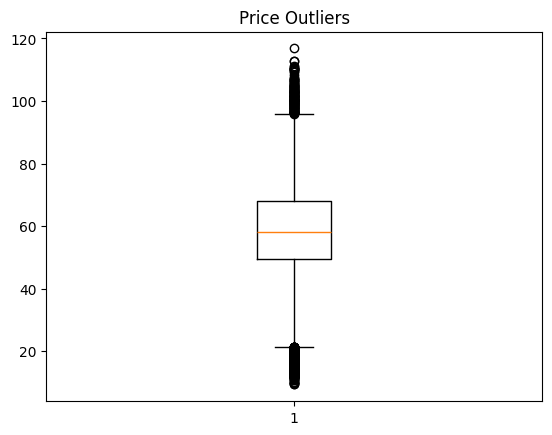

In [578]:
import matplotlib.pyplot as plt

plt.boxplot(df['price actual'])
plt.title("Price Outliers")
plt.show()

In [ ]:

from sklearn.preprocessing import RobustScaler

scaler_price = RobustScaler()
scaler_demand = RobustScaler()

df['price_scaled'] = scaler_price.fit_transform(df[['price actual']])
df['demand_scaled'] = scaler_demand.fit_transform(df[['total load actual']])


"\nfrom sklearn.preprocessing import RobustScaler\n\nscaler_price = RobustScaler()\nscaler_demand = RobustScaler()\n\ndf['price_scaled'] = scaler_price.fit_transform(df[['price actual']])\ndf['demand_scaled'] = scaler_demand.fit_transform(df[['total load actual']])\n"

In [580]:
constant_columns = [col for col in df.columns if df[col].nunique() == 1]
print("Dropping constant columns:", constant_columns)
df = df.drop(columns=constant_columns)

Dropping constant columns: []


In [581]:
df.select_dtypes(include=['object']).columns 


Index([], dtype='str')

“Since the dataset contains no categorical variables, traditional encoding techniques such as One-Hot or Label Encoding were not required. However, cyclical time features (hour, month, day) were transformed using sine and cosine encoding to preserve periodic relationships


In [582]:

#STEP 10: SELECT FEATURES FOR MODELS

demand_features = [
    # time
    'hour', 'day_of_week', 'month', 'is_weekend',

    # lag demand
    'demand_lag_1h',
    'demand_lag_24h',
    'demand_lag_168h',

    # lag price influence
    'price_lag_1h',
    'price_lag_24h',
    

    # generation
    'renewable', 'fossil', 'nuclear',

    # system state
    'renewable_pct',

    # rolling
    'demand_avg_24h',
    'price_avg_24h'
]



price_features = [
    # time
    'hour', 'day_of_week', 'month', 'is_weekend',

    # price history
    'price_lag_1h',
    'price_lag_24h',

    # demand influence
    'demand_lag_1h',
    'demand_lag_24h',
    

    # generation (supply side)
    'renewable', 'fossil', 'nuclear',

    # system balance
    'renewable_pct',

    # rolling
    'price_avg_24h',
    'demand_avg_24h'
]


In [583]:

y_demand = 'total load actual'
y_price = 'price actual'


“Feature extraction was performed to transform raw time-series data into supervised learning format by introducing lag variables, rolling statistics, and cyclical time encodings.”

In [584]:
#constant_columns = [col for col in df.columns if df[col].nunique() == 1]
#print(constant_columns)

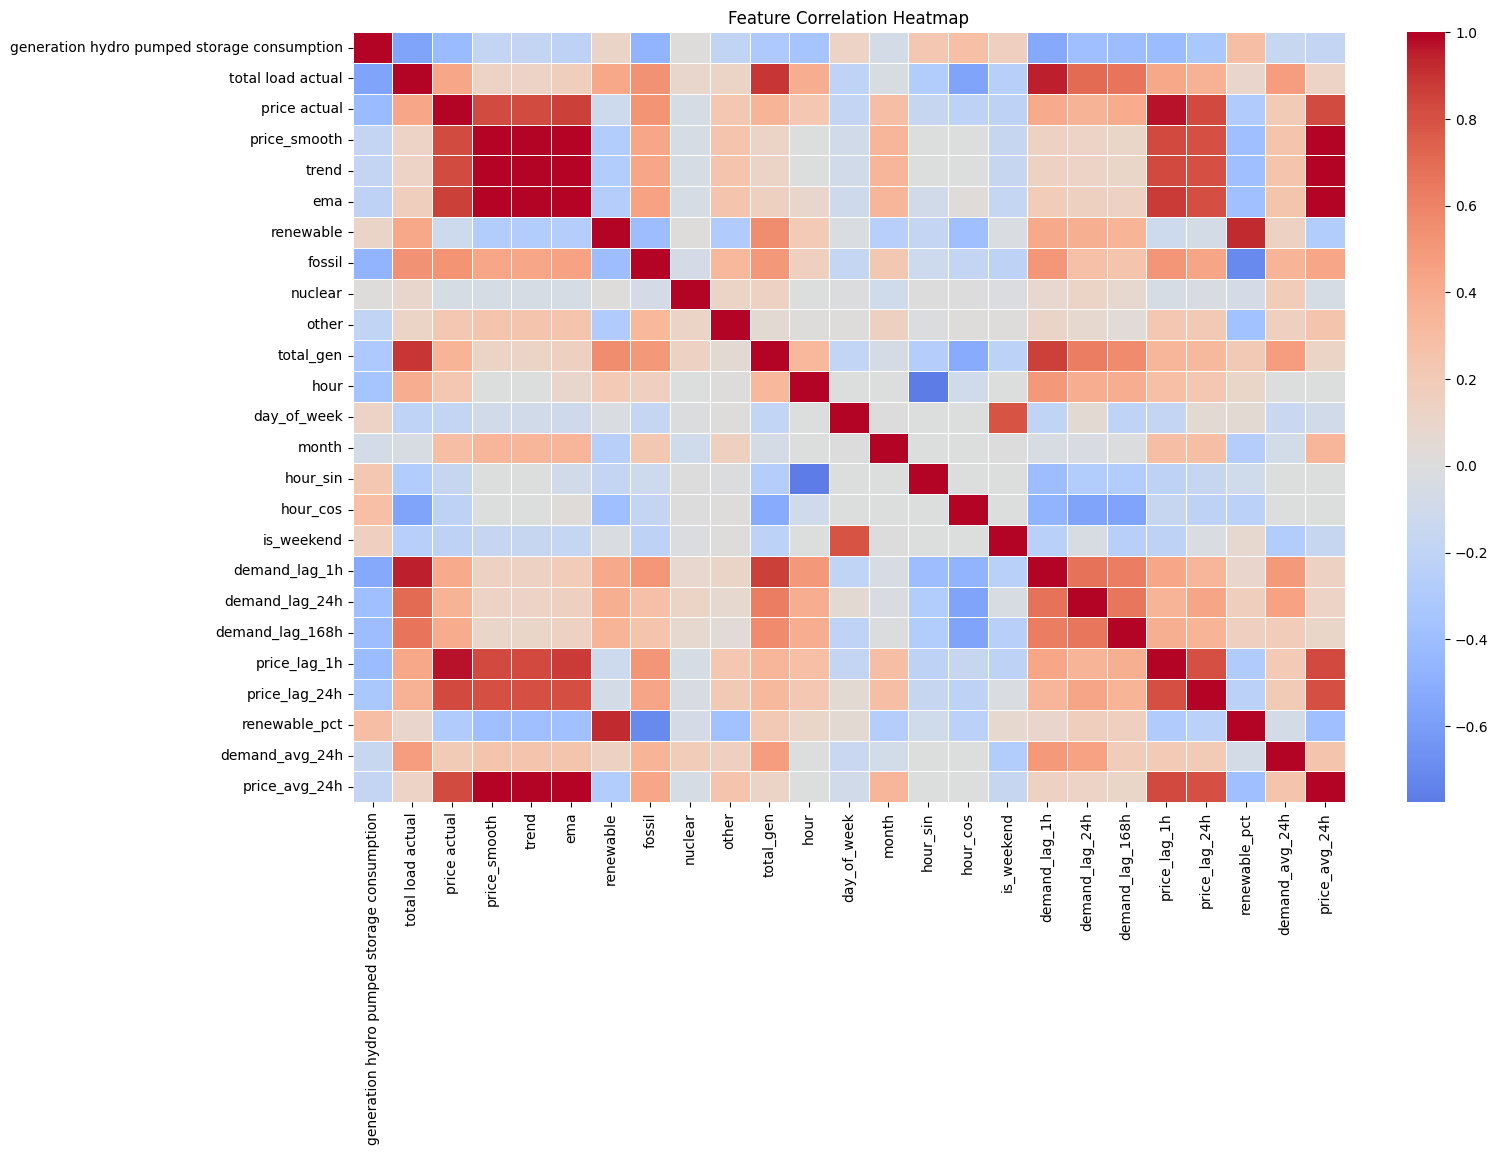

In [585]:
# select only numeric columns (important step)
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(16, 10))
sns.heatmap(
    corr_matrix,
    annot=False,      # set True if you want values shown
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Heatmap")
plt.show()

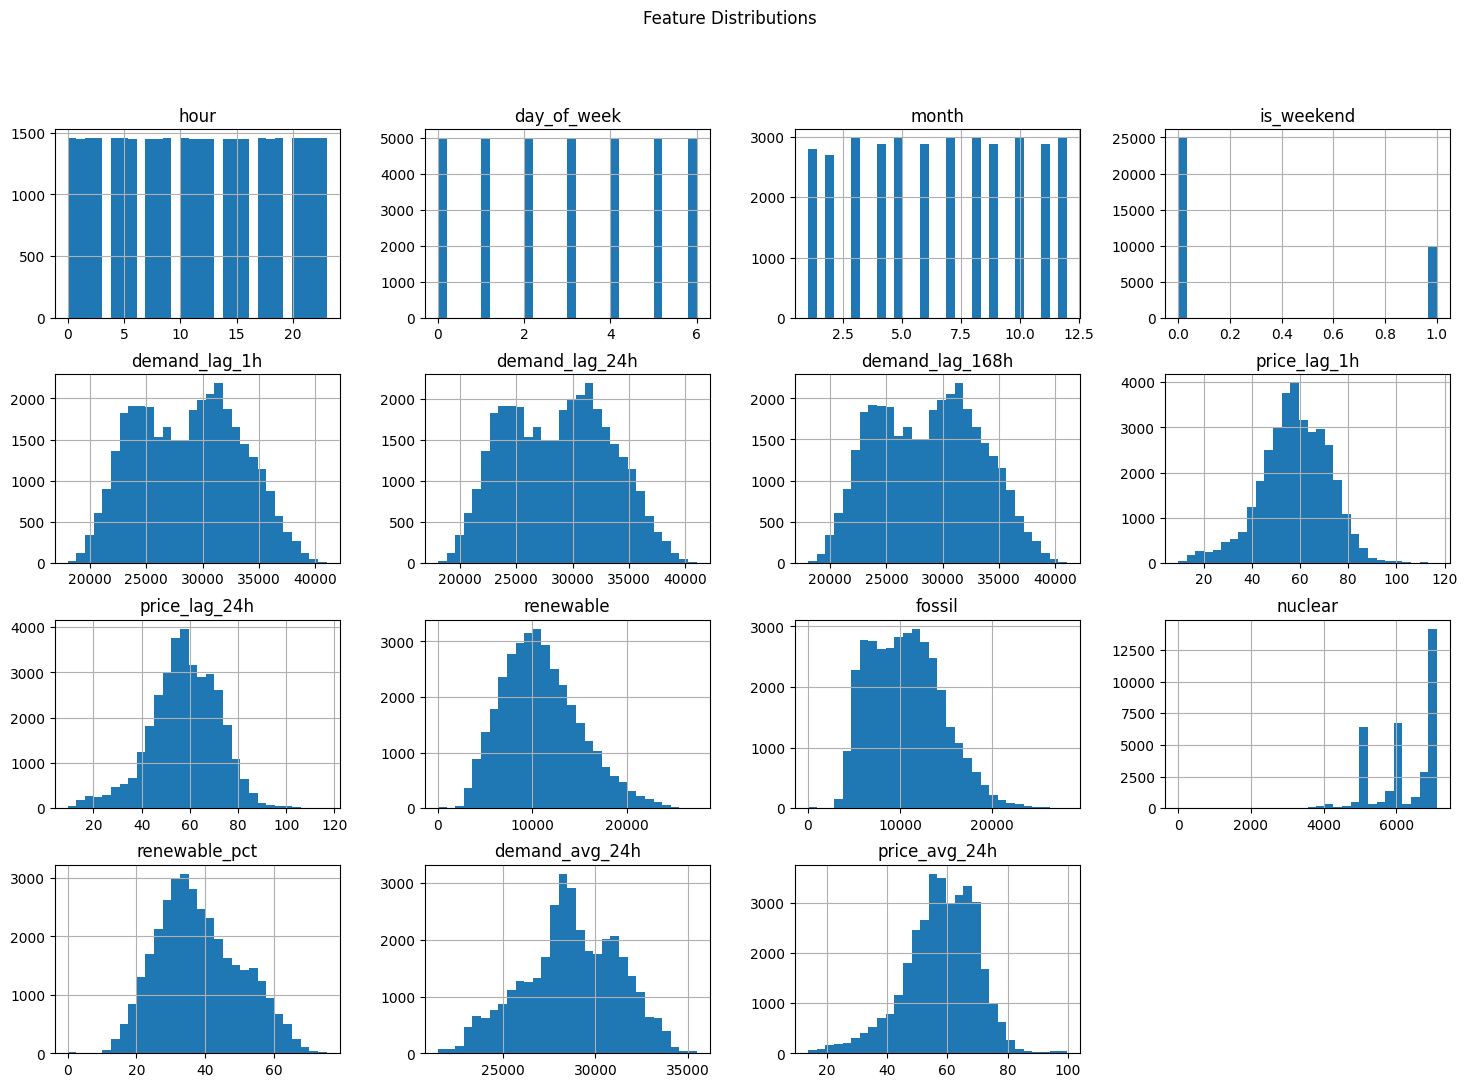

In [586]:

df[demand_features].hist(figsize=(18,12), bins=30)
plt.suptitle("Feature Distributions")
plt.show()


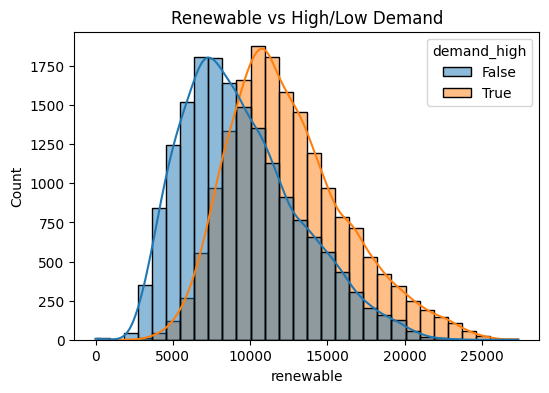

In [587]:

df['demand_high'] = df['total load actual'] > df['total load actual'].median()

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='renewable', hue='demand_high', bins=30, kde=True)
plt.title("Renewable vs High/Low Demand")
plt.show()


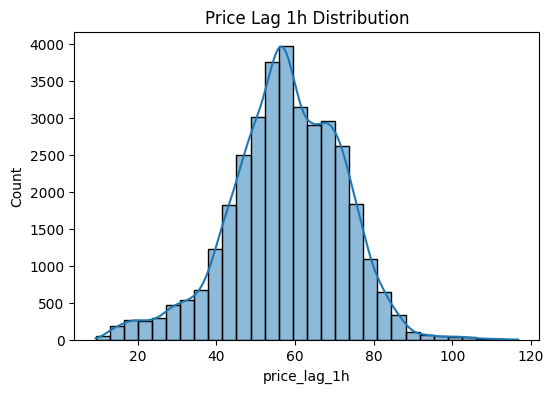

In [588]:

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='price_lag_1h', bins=30, kde=True)
plt.title("Price Lag 1h Distribution")
plt.show()


In [589]:
'''
# ==========================================
# 1. DEFINE STRUCTURAL FEATURES (NO LAGS)
# ==========================================
# We strip away everything that references the past ('lag', 'avg', 'ema')
structural_features = [
    'hour', 'day_of_week', 'month', 'is_weekend',
    'renewable', 'fossil', 'nuclear', 'renewable_pct'
]

print("--- EXECUTING THE STRUCTURAL ACID TEST ---")
print(f"Features utilized: {structural_features}")

# ==========================================
# 2. SANITIZE AND RE-SPLIT DATA
# ==========================================
# Target columns
targets = ['total load actual', 'price actual']

# Final purge of NaNs in our chosen features and targets
df_structural = df.dropna(subset=structural_features + targets).copy()

# Chronological split (80/20)
split_idx = int(len(df_structural) * 0.8)

# Demand Data
X_d_struct = df_structural[structural_features]
y_d_struct = df_structural['total load actual']
X_train_d_s, X_test_d_s = X_d_struct.iloc[:split_idx], X_d_struct.iloc[split_idx:]
y_train_d_s, y_test_d_s = y_d_struct.iloc[:split_idx], y_d_struct.iloc[split_idx:]

# Price Data
X_p_struct = df_structural[structural_features]
y_p_struct = df_structural['price actual']
X_train_p_s, X_test_p_s = X_p_struct.iloc[:split_idx], X_p_struct.iloc[split_idx:]
y_train_p_s, y_test_p_s = y_p_struct.iloc[:split_idx], y_p_struct.iloc[split_idx:]

# ==========================================
# 3. TRAIN AND EVALUATE (DEMAND)
# ==========================================
lr_d_s = LinearRegression().fit(X_train_d_s, y_train_d_s)
y_pred_d_s = lr_d_s.predict(X_test_d_s)

mae_d_s = mean_absolute_error(y_test_d_s, y_pred_d_s)
r2_d_s = r2_score(y_test_d_s, y_pred_d_s)
nmae_d_s = mae_d_s / y_test_d_s.mean() # 0 to 1 scale

# ==========================================
# 4. TRAIN AND EVALUATE (PRICE)
# ==========================================
lr_p_s = LinearRegression().fit(X_train_p_s, y_train_p_s)
y_pred_p_s = lr_p_s.predict(X_test_p_s)

mae_p_s = mean_absolute_error(y_test_p_s, y_pred_p_s)
r2_p_s = r2_score(y_test_p_s, y_pred_p_s)
nmae_p_s = mae_p_s / y_test_p_s.mean() # 0 to 1 scale

# ==========================================
# 5. PRINT COMPARATIVE RESULTS
# ==========================================
print("\n[DEMAND: STRUCTURAL ONLY]")
print(f"R-Squared Score: {r2_d_s:.4f}")
print(f"Normalized MAE:  {nmae_d_s:.4f} (Proportion of 1.0)")

print("\n[PRICE: STRUCTURAL ONLY]")
print(f"R-Squared Score: {r2_p_s:.4f}")
print(f"Normalized MAE:  {nmae_p_s:.4f} (Proportion of 1.0)")

# ==========================================
# 6. VISUALIZE THE "CRUTCHLESS" MODEL (DEMAND)
# ==========================================
plt.figure(figsize=(15, 5))
plt.plot(y_test_d_s.index[:168], y_test_d_s.iloc[:168], label='Actual', color='#007acc', alpha=0.8)
plt.plot(y_test_d_s.index[:168], y_pred_d_s[:168], label='Structural Prediction', color='red', linestyle='--')
plt.title("The Acid Test: Predicting without Historical Lags (First Week)")
plt.legend()
plt.show()
''' 

'\n# ==========================================\n# 1. DEFINE STRUCTURAL FEATURES (NO LAGS)\n# ==========================================\n# We strip away everything that references the past (\'lag\', \'avg\', \'ema\')\nstructural_features = [\n    \'hour\', \'day_of_week\', \'month\', \'is_weekend\',\n    \'renewable\', \'fossil\', \'nuclear\', \'renewable_pct\'\n]\n\nprint("--- EXECUTING THE STRUCTURAL ACID TEST ---")\nprint(f"Features utilized: {structural_features}")\n\n# ==========================================\n# 2. SANITIZE AND RE-SPLIT DATA\n# ==========================================\n# Target columns\ntargets = [\'total load actual\', \'price actual\']\n\n# Final purge of NaNs in our chosen features and targets\ndf_structural = df.dropna(subset=structural_features + targets).copy()\n\n# Chronological split (80/20)\nsplit_idx = int(len(df_structural) * 0.8)\n\n# Demand Data\nX_d_struct = df_structural[structural_features]\ny_d_struct = df_structural[\'total load actual\']\nX

In [590]:
# ==========================================
# CRITICAL CORRECTION: PREVENTING DATA LEAKAGE
# ==========================================
df['demand_avg_24h'] = df['total load actual'].rolling(window=24, min_periods=1).mean().shift(1)
df['price_avg_24h'] = df['price actual'].rolling(window=24, min_periods=1).mean().shift(1)

# ==========================================
# THE FINAL PURGE: REMOVING ALL HIDDEN NaNs
# ==========================================
# Combine all features we care about into one list
all_required_columns = list(set(demand_features + price_features + ['total load actual', 'price actual']))

# Drop any row that is missing data in ANY of these columns
rows_before = len(df)
df = df.dropna(subset=all_required_columns).copy()
print(f"Purged {rows_before - len(df)} imperfect rows. Dataset is now perfectly sanitized.")

# ==========================================
# STEP 11: DEFINE MATRICES AND TARGETS
# ==========================================
X_demand = df[demand_features]
y_demand = df['total load actual']

X_price = df[price_features]
y_price = df['price actual']

# ==========================================
# STEP 12: CHRONOLOGICAL TRAIN-TEST SPLIT
# ==========================================
split = int(len(df) * 0.8)

# Split Demand Data
X_train_d = X_demand.iloc[:split]
X_test_d  = X_demand.iloc[split:]
y_train_d = y_demand.iloc[:split]
y_test_d  = y_demand.iloc[split:]

# Split Price Data
X_train_p = X_price.iloc[:split]
X_test_p  = X_price.iloc[split:]
y_train_p = y_price.iloc[:split]
y_test_p  = y_price.iloc[split:]

print(f"Demand Split - Training Records: {len(X_train_d)}, Testing Records: {len(X_test_d)}")
print(f"Price Split  - Training Records: {len(X_train_p)}, Testing Records: {len(X_test_p)}")

Purged 82 imperfect rows. Dataset is now perfectly sanitized.
Demand Split - Training Records: 27822, Testing Records: 6956
Price Split  - Training Records: 27822, Testing Records: 6956


--- LEVEL 1: LINEAR REGRESSION BASELINE ---

Training Linear Regression on Demand Data...
[DEMAND FORECASTING RESULTS]
MAE:  825.98 MW
RMSE: 1075.21 MW
MAPE: 2.90%
R2:   0.9434

Training Linear Regression on Price Data...
[PRICE FORECASTING RESULTS]
MAE:  €2.07
RMSE: €2.81
MAPE: 3.51%
R2:   0.9402

--- PURE PROPORTION (0 to 1 SCALE) ---
Demand NMAE:  0.0286
Demand NRMSE: 0.0373
Price NMAE:   0.0317
Price NRMSE:  0.0431


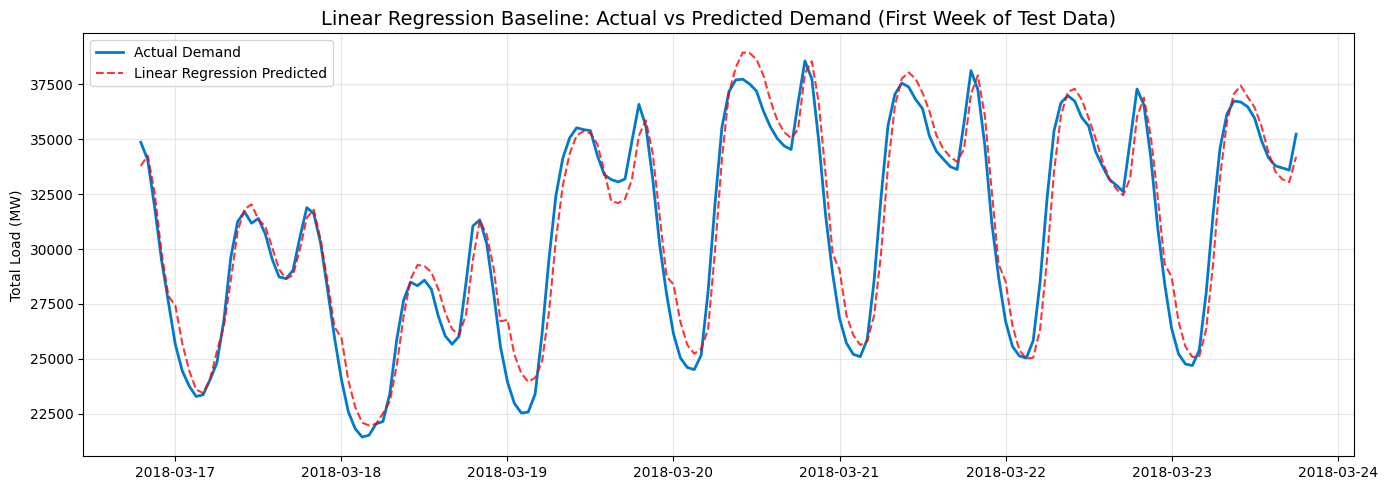

In [591]:
print("--- LEVEL 1: LINEAR REGRESSION BASELINE ---\n")

# ==========================================
# 1. TRAIN AND EVALUATE: DEMAND
# ==========================================
# Initialize the model
lr_demand = LinearRegression()

# Train the model
print("Training Linear Regression on Demand Data...")
lr_demand.fit(X_train_d, y_train_d)

# Predict the future using the test features
y_pred_d_lr = lr_demand.predict(X_test_d)

# Calculate Evaluation Metrics
mae_d = mean_absolute_error(y_test_d, y_pred_d_lr)
rmse_d = np.sqrt(mean_squared_error(y_test_d, y_pred_d_lr))
mape_d = mean_absolute_percentage_error(y_test_d, y_pred_d_lr) * 100
r2_d = r2_score(y_test_d, y_pred_d_lr)

print("[DEMAND FORECASTING RESULTS]")
print(f"MAE:  {mae_d:.2f} MW")
print(f"RMSE: {rmse_d:.2f} MW")
print(f"MAPE: {mape_d:.2f}%")
print(f"R2:   {r2_d:.4f}\n")

# ==========================================
# 2. TRAIN AND EVALUATE: PRICE
# ==========================================
# Initialize the model
lr_price = LinearRegression()

# Train the model
print("Training Linear Regression on Price Data...")
lr_price.fit(X_train_p, y_train_p)

# Predict the future using the test features
y_pred_p_lr = lr_price.predict(X_test_p)

# Calculate Evaluation Metrics
mae_p = mean_absolute_error(y_test_p, y_pred_p_lr)
rmse_p = np.sqrt(mean_squared_error(y_test_p, y_pred_p_lr))
mape_p = mean_absolute_percentage_error(y_test_p, y_pred_p_lr) * 100
r2_p = r2_score(y_test_p, y_pred_p_lr)

print("[PRICE FORECASTING RESULTS]")
print(f"MAE:  €{mae_p:.2f}")
print(f"RMSE: €{rmse_p:.2f}")
print(f"MAPE: {mape_p:.2f}%")
print(f"R2:   {r2_p:.4f}\n")
# ==========================================
# NORMALIZED METRICS (0 to 1 Scale)
# ==========================================
# Calculate the mean (average) of the actual test data
mean_demand = y_test_d.mean()
mean_price = y_test_p.mean()

# Normalize the errors
nmae_d = mae_d / mean_demand
nrmse_d = rmse_d / mean_demand

nmae_p = mae_p / mean_price
nrmse_p = rmse_p / mean_price

print("--- PURE PROPORTION (0 to 1 SCALE) ---")
print(f"Demand NMAE:  {nmae_d:.4f}")
print(f"Demand NRMSE: {nrmse_d:.4f}")
print(f"Price NMAE:   {nmae_p:.4f}")
print(f"Price NRMSE:  {nrmse_p:.4f}")

# ==========================================
# 3. VISUALIZE THE BASELINE (DEMAND)
# ==========================================
# Plotting the first 168 hours (Exactly one week) of the test set
plt.figure(figsize=(14, 5))
plt.plot(y_test_d.index[:168], y_test_d.iloc[:168], label='Actual Demand', color='#007acc', linewidth=2)
plt.plot(y_test_d.index[:168], y_pred_d_lr[:168], label='Linear Regression Predicted', color='red', linestyle='--', alpha=0.8)

plt.title("Linear Regression Baseline: Actual vs Predicted Demand (First Week of Test Data)", fontsize=14)
plt.ylabel("Total Load (MW)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: x and y must be the same size

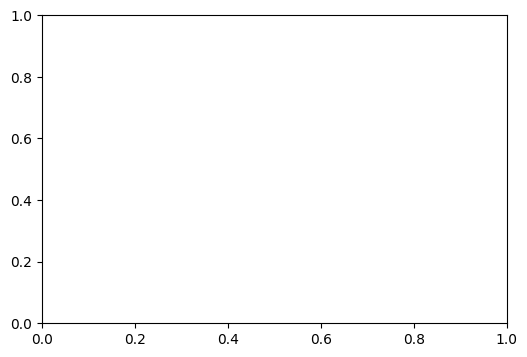

In [593]:
plt.figure(figsize=(6,4))
plt.scatter(y_test_d, y_demand, alpha=0.3)
plt.plot([y_test_d.min(), y_test_d.max()],
         [y_test_d.min(), y_test_d.max()],
         color='red')
plt.title("Actual vs Predicted (Spike Check)")
plt.show()